<a href="https://colab.research.google.com/github/MrRichar02/Laboratorio-Imagenes-2/blob/main/lab2_imagenes_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte 1: Filtros

1\) (30%) Investigar/Consultar y definir los siguientes filtros (la investigación debe contener la fórmula matemática, un ejemplo y su explicación):


A. Filtro de media

B. Filtro de mediana

C. Filtro logarítmico

D. Filtro de cuadro normalizado

E. Filtro gaussiano

F. Filtro Laplace

G. Filtro Sobel

H. Filtro Canny


2\) De los filtros definidos en el numeral describir ventajas y desventajas

3\) De los filtros definidos en el numeral 1 programar un ejemplo usando opencv ó Matlab por cada literal  

#PARTE 2: (70%) Descriptores

- [ ] Generar un banco de imágenes  

- [ ] Hacer preprocesamiento a la imagen (mínimo resize o algún filtro de los estudiados)

- [ ] Definir características HOG y otra adicional SIFT, SURF, LAB, LBP(local binay patterns), gabor wavelets, Haralick  y extraer dichas características a las imágenes.

- [ ] Entrenar una red neuronal/svm  para cada set de características obtenidas en el punto anterior.

- [ ] Investigar métricas (por ejemplo: Accuracy, precisión, matriz de confusión, falsos positivos, falsos negativos, medidas F-Score)

- [ ] Aplicar el detector sobre nuevas imágenes y hacer una interfaz gráfica que cargue sus imágenes y aplique su clasificador

## Importación del datset

el datset utilizado fue [animals10](https://www.kaggle.com/datasets/alessiocorrado99/animals10)

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animals10' dataset.
Path to dataset files: /kaggle/input/animals10


In [ ]:
import os
import pandas as pd

Basado en la estructura típica de este dataset en Kaggle, las imágenes suelen estar ubicadas en un subdirectorio llamado `raw-img`. Asumiré esta estructura y procederé a contar las imágenes en cada carpeta de clase.

In [ ]:
# Define the path to the images, assuming a 'raw-img' subdirectory
image_dir = os.path.join(path, 'raw-img')

# Dictionary to store class counts
class_counts = {}

# Iterate through class directories and count images
for class_name_italian in os.listdir(image_dir):
    class_path = os.path.join(image_dir, class_name_italian)
    if os.path.isdir(class_path):
        # Count only image files (e.g., .jpg, .jpeg, .png)
        num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))])
        class_counts[class_name_italian] = num_images

# Convert to DataFrame for easier manipulation and plotting
df_counts = pd.DataFrame(class_counts.items(), columns=['Class_Italian', 'Count'])

Ahora cargamos el diccionario de traducción para las clases.

In [ ]:
# Load the translate dictionary from the translate.py file
translate_file_path = os.path.join(path, 'translate.py')
with open(translate_file_path, 'r') as f:
    exec(f.read())
# Add missing translation for 'ragno' (spider in English)
if 'ragno' not in translate: # This check handles if translate.py is updated in the future
    translate['ragno'] = 'spider'

In [ ]:
# Translate Italian class names to English
df_counts['Class_English'] = df_counts['Class_Italian'].map(translate)

# Sort by count for better visualization
df_counts = df_counts.sort_values(by='Count', ascending=False)

# Display the DataFrame with counts and translated names
display(df_counts)

,Class_Italian,Count,Class_English
8,cane,4863,dog
6,ragno,4821,spider
5,gallina,3098,chicken
0,cavallo,2623,horse
9,farfalla,2112,butterfly
7,mucca,1866,cow
4,scoiattolo,1862,squirrel
1,pecora,1820,sheep
3,gatto,1668,cat
2,elefante,1446,elephant


Ahora, visualicemos la distribución de imágenes por clase usando un gráfico de barras con los nombres traducidos al inglés.

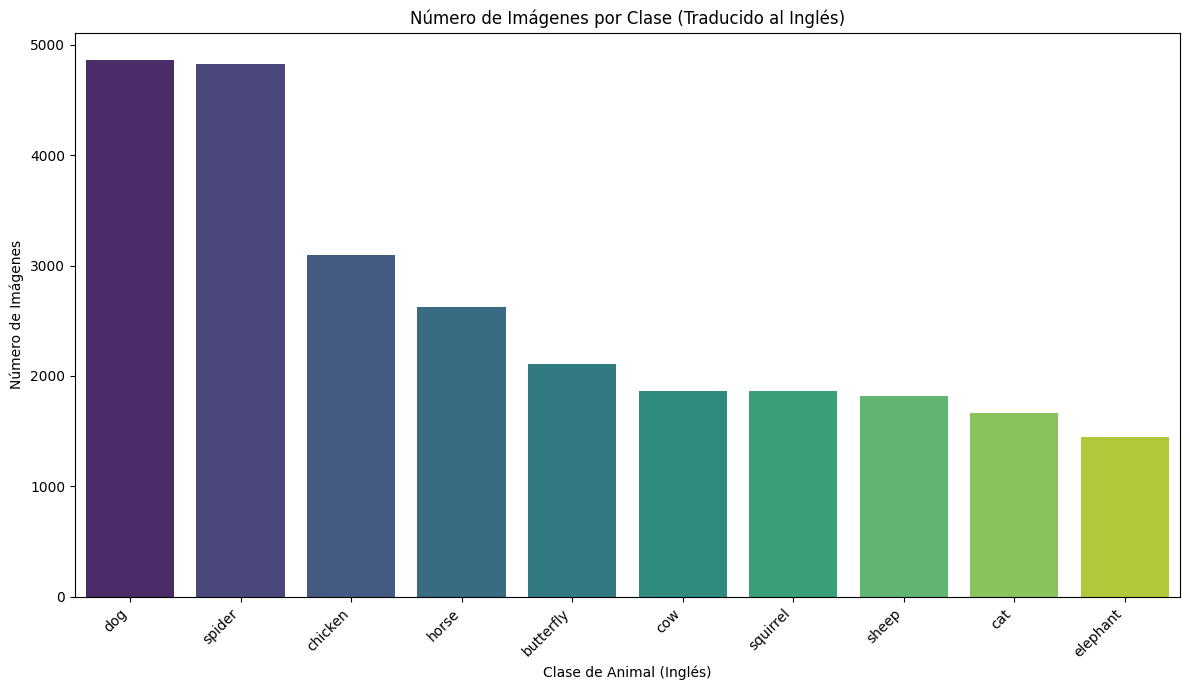

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Class_English', y='Count', data=df_counts, palette='viridis', hue='Class_English', legend=False)
plt.title('Número de Imágenes por Clase (Traducido al Inglés)')
plt.xlabel('Clase de Animal (Inglés)')
plt.ylabel('Número de Imágenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1. Extracción de Características HOG (Histograma de Gradientes Orientados)

Las características HOG son descriptores de apariencia que se utilizan comúnmente en el procesamiento de imágenes para la detección de objetos. Funcionan calculando la distribución de la intensidad de los gradientes en una imagen. Estos gradientes, que representan cambios en la intensidad de los píxeles, son una buena indicación de los contornos y las formas de los objetos.

En este paso, iteraremos sobre todas las imágenes del dataset, las preprocesaremos (cambio de tamaño y conversión a escala de grises) y luego extraeremos sus características HOG. Estas características se almacenarán junto con sus etiquetas de clase para su posterior uso en el entrenamiento de modelos de clasificación.

In [ ]:
import numpy as np
from skimage.io import imread
from skimage.transform import resize
from skimage.feature import hog
from tqdm.notebook import tqdm # For progress bar
import joblib
from joblib import Parallel, delayed

# Define HOG parameters
orientations = 9
pixels_per_cell = (8, 8)
cells_per_block = (2, 2)
transform_sqrt = True
block_norm = 'L2-Hys'

# Define target image size for HOG (HOG works best with consistent input size)
target_image_size = (128, 128)

# Function to process a single image and extract HOG features
def process_image_for_hog(image_path, class_name_english):
    try:
        image = imread(image_path)

        resized_image = resize(image, target_image_size, anti_aliasing=True, preserve_range=True)
        if resized_image.ndim == 3 and resized_image.shape[2] == 3:
            resized_image = np.dot(resized_image[...,:3], [0.2989, 0.5870, 0.1140])

        hog_features = hog(resized_image, orientations=orientations,
                           pixels_per_cell=pixels_per_cell,
                           cells_per_block=cells_per_block,
                           transform_sqrt=transform_sqrt,
                           block_norm=block_norm,
                           feature_vector=True)
        return hog_features, class_name_english
    except Exception as e:
        print(f"Error procesando la imagen {image_path}: {e}")
        return None, None

print("Comenzando la extracción de características HOG en paralelo...")

hog_features_list = []
labels_list = []

# Collect all image paths and their corresponding class names
all_image_data = []
for class_name_italian in os.listdir(image_dir):
    class_path = os.path.join(image_dir, class_name_italian)
    if os.path.isdir(class_path):
        class_name_english = translate.get(class_name_italian, 'Unknown')
        for image_filename in os.listdir(class_path):
            if image_filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                image_path = os.path.join(class_path, image_filename)
                all_image_data.append((image_path, class_name_english))

# Use joblib to parallelize the processing
# n_jobs=-1 means use all available CPU cores
results = Parallel(n_jobs=-1)(delayed(process_image_for_hog)(img_path, class_name)
                                for img_path, class_name in tqdm(all_image_data, desc="Extrayendo HOG"))

# Filter out any failed extractions and append to lists
for features, label in results:
    if features is not None:
        hog_features_list.append(features)
        labels_list.append(label)

print("Extracción de características HOG completada.")

Comenzando la extracción de características HOG en paralelo...


Extrayendo HOG:   0%|          | 0/26179 [00:00<?, ?it/s]

Extracción de características HOG completada.


### 2. Preparación de los Datos para el Entrenamiento

Una vez extraídas todas las características HOG, las convertimos en arrays NumPy. Esto es un formato estándar y eficiente para el entrenamiento de modelos de aprendizaje automático. El array `X` contendrá todas las características HOG de las imágenes, mientras que el array `y` contendrá las etiquetas de clase correspondientes.

También se mostrará la forma de estos arrays para verificar que los datos están estructurados correctamente.

In [ ]:
# Convert lists to NumPy arrays
X = np.array(hog_features_list)
y = np.array(labels_list)

print(f"Forma del array de características (X): {X.shape}")
print(f"Forma del array de etiquetas (y): {y.shape}")

# Display a small sample of features and labels
print("\nPrimeras 5 filas de características HOG (parcial):")
print(X[:5, :10]) # Displaying first 10 dimensions for brevity
print("\nPrimeras 5 etiquetas:")
print(y[:5])

Forma del array de características (X): (26129, 8100)
Forma del array de etiquetas (y): (26129,)

Primeras 5 filas de características HOG (parcial):
[[2.25888820e-01 1.59482007e-01 1.32951463e-01 1.69231315e-01
  2.25888820e-01 2.03439398e-01 3.28791921e-02 1.73399711e-01
  1.35282408e-01 2.25888820e-01]
 [2.82216711e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
  4.64739305e-01 0.00000000e+00 1.97930996e-01 0.00000000e+00
  1.73469021e-01 2.61160273e-01]
 [7.72406116e-02 4.15880959e-02 6.35968179e-02 1.04627940e-01
  1.56680743e-01 8.80007353e-02 4.36829061e-02 3.46888316e-02
  2.29277611e-02 1.97515157e-01]
 [2.03994757e-01 4.31768734e-02 6.06245435e-02 1.01424677e-02
  4.82632992e-02 8.28964457e-02 3.08651761e-02 1.58884990e-01
  2.40445920e-01 2.40445920e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.39957948e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 1.58128670e-02]]

Primeras 5 etiquetas:
['horse' 'horse' 'horse' 'horse' 'horse']


### 3. Guardar las Características y Etiquetas Extraídas

Para poder reutilizar las características HOG sin tener que volver a extraerlas cada vez que se ejecute el notebook, es una buena práctica guardarlas en el disco. Utilizaremos `numpy.save` para almacenar los arrays `X` e `y` en formato `.npy`.

Esto es especialmente útil para datasets grandes, ya que la extracción de características puede ser un proceso que consume mucho tiempo.

In [ ]:
import joblib # Often used for saving ML-related objects

# Define paths to save the features and labels
# Change save_dir to a writable location, e.g., /content/
save_dir = os.path.join('/content/', 'processed_features')
os.makedirs(save_dir, exist_ok=True)

features_path = os.path.join(save_dir, 'hog_features.npy')
labels_path = os.path.join(save_dir, 'hog_labels.npy')

# Save the features and labels
np.save(features_path, X)
np.save(labels_path, y)

print(f"Características HOG guardadas en: {features_path}")
print(f"Etiquetas HOG guardadas en: {labels_path}")

# You can also use joblib for more complex objects, but numpy.save is fine for arrays.
# joblib.dump(X, features_path.replace('.npy', '.pkl'))
# joblib.dump(y, labels_path.replace('.npy', '.pkl'))
# print(f"Características HOG guardadas (joblib): {features_path.replace('.npy', '.pkl')}")

Características HOG guardadas en: /content/processed_features/hog_features.npy
Etiquetas HOG guardadas en: /content/processed_features/hog_labels.npy


### 4. Cargar Datos y Preprocesar Etiquetas para PyTorch

Primero, cargaremos las características HOG y las etiquetas guardadas. Luego, convertiremos las etiquetas de texto a valores numéricos usando `LabelEncoder` para que PyTorch pueda procesarlas. Finalmente, convertiremos tanto las características como las etiquetas a tensores de PyTorch, preparándolas para el entrenamiento.

In [ ]:
import torch
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Load the saved HOG features and labels
features_path = os.path.join(save_dir, 'hog_features.npy')
labels_path = os.path.join(save_dir, 'hog_labels.npy')

X_loaded = np.load(features_path)
y_loaded = np.load(labels_path)

print(f"Características HOG cargadas: {X_loaded.shape}")
print(f"Etiquetas HOG cargadas: {y_loaded.shape}")

# Encode labels to numerical format
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_loaded)
num_classes = len(label_encoder.classes_)
print(f"Número de clases: {num_classes}")

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_loaded, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

print(f"Forma del tensor X: {X_tensor.shape}")
print(f"Forma del tensor y: {y_tensor.shape}")

Características HOG cargadas: (26129, 8100)
Etiquetas HOG cargadas: (26129,)
Número de clases: 10
Forma del tensor X: torch.Size([26129, 8100])
Forma del tensor y: torch.Size([26129])


### 5. Definición del Modelo de Red Neuronal de Dos Capas

Crearemos una red neuronal simple con dos capas ocultas utilizando PyTorch. Esta red tomará las características HOG como entrada y producirá una salida para cada una de las clases de animales, utilizando funciones de activación ReLU y Dropout para evitar el sobreajuste.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# Define the Neural Network
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3) # Added dropout for regularization
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3) # Added dropout for regularization
        self.fc3 = nn.Linear(hidden_size2, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.dropout1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.dropout2(out)
        out = self.fc3(out)
        return out

# Hyperparameters for the model
input_size = X_tensor.shape[1] # Number of HOG features
hidden_size1 = 512 # First hidden layer size
hidden_size2 = 256 # Second hidden layer size

print(f"Tamaño de entrada de la red: {input_size}")
print(f"Tamaño de la primera capa oculta: {hidden_size1}")
print(f"Tamaño de la segunda capa oculta: {hidden_size2}")
print(f"Número de clases de salida: {num_classes}")

Tamaño de entrada de la red: 8100
Tamaño de la primera capa oculta: 512
Tamaño de la segunda capa oculta: 256
Número de clases de salida: 10


### 6. Entrenamiento del Modelo con Validación Cruzada y Evaluación

Aquí implementaremos la validación cruzada para entrenar el modelo. Dividiremos los datos en 10 pliegues (folds), usando el 90% para entrenamiento y el 10% para validación en cada iteración. Después de cada fold, calcularemos y mostraremos la exactitud, sensibilidad (recall) y precisión. Finalmente, almacenaremos estos resultados para un resumen posterior.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, precision_score
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Hyperparameters for training
num_epochs = 10
batch_size = 64
learning_rate = 0.001

# Initialize StratifiedKFold for cross-validation (10% for validation)
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

for fold, (train_index, val_index) in enumerate(kf.split(X_tensor, y_tensor)):
    print(f"\n--- Fold {fold+1}/{kf.n_splits} ---")

    # Split data for the current fold
    X_train, X_val = X_tensor[train_index], X_tensor[val_index]
    y_train, y_val = y_tensor[train_index], y_tensor[val_index]

    # Create DataLoader for training and validation sets
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

    # Initialize model, loss, and optimizer for each fold
    model = NeuralNet(input_size, hidden_size1, hidden_size2, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    model.train()
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print (f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

    # Evaluation loop
    model.eval()
    with torch.no_grad():
        all_labels = []
        all_predictions = []
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

        accuracy = accuracy_score(all_labels, all_predictions)
        # Use 'weighted' average for precision and recall for multiclass classification
        precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
        recall = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)

        print(f'Fold {fold+1} Validation Accuracy: {accuracy:.4f}')
        print(f'Fold {fold+1} Validation Sensitivity (Recall): {recall:.4f}')
        print(f'Fold {fold+1} Validation Precision: {precision:.4f}')

        results.append({
            'Fold': fold + 1,
            'Accuracy': accuracy,
            'Sensitivity': recall,
            'Precision': precision
        })

print("\nEntrenamiento con validación cruzada completado.")

Usando dispositivo: cpu

--- Fold 1/10 ---
Epoch [1/10], Loss: 1.5168
Epoch [2/10], Loss: 1.7211
Epoch [3/10], Loss: 1.8899
Epoch [4/10], Loss: 1.6321
Epoch [5/10], Loss: 1.5634
Epoch [6/10], Loss: 1.4590
Epoch [7/10], Loss: 1.2546
Epoch [8/10], Loss: 1.2736
Epoch [9/10], Loss: 1.5765
Epoch [10/10], Loss: 1.2813
Fold 1 Validation Accuracy: 0.4604
Fold 1 Validation Sensitivity (Recall): 0.4604
Fold 1 Validation Precision: 0.4621

--- Fold 2/10 ---
Epoch [1/10], Loss: 1.2254
Epoch [2/10], Loss: 1.8037
Epoch [3/10], Loss: 1.7311
Epoch [4/10], Loss: 1.8006
Epoch [5/10], Loss: 1.6109
Epoch [6/10], Loss: 1.7621
Epoch [7/10], Loss: 1.6056
Epoch [8/10], Loss: 1.7689
Epoch [9/10], Loss: 1.5416
Epoch [10/10], Loss: 1.6457
Fold 2 Validation Accuracy: 0.4386
Fold 2 Validation Sensitivity (Recall): 0.4386
Fold 2 Validation Precision: 0.4469

--- Fold 3/10 ---
Epoch [1/10], Loss: 1.6982
Epoch [2/10], Loss: 1.9702
Epoch [3/10], Loss: 2.0307
Epoch [4/10], Loss: 1.6461
Epoch [5/10], Loss: 1.3339
Epoch 

### 7. Resumen de Rendimiento de los Modelos

Finalmente, presentaremos una tabla con los resultados de exactitud, sensibilidad y precisión de cada fold, ordenada de mayor a menor exactitud. Esto nos dará una visión general del rendimiento del modelo a lo largo de las diferentes particiones de los datos.

In [ ]:
import pandas as pd

df_results = pd.DataFrame(results)
# Sort by accuracy in descending order
df_results_sorted = df_results.sort_values(by='Accuracy', ascending=False)

print("\nResumen de los resultados de validación cruzada:")
display(df_results_sorted)


Resumen de los resultados de validación cruzada:


,Fold,Accuracy,Sensitivity,Precision
5,6,0.479143,0.479143,0.487387
0,1,0.460390,0.460390,0.462096
4,5,0.460008,0.460008,0.477821
7,8,0.453884,0.453884,0.465102
8,9,0.452354,0.452354,0.475965
6,7,0.446613,0.446613,0.451097
9,10,0.441807,0.441807,0.452560
1,2,0.438576,0.438576,0.446855
3,4,0.436663,0.436663,0.430242
2,3,0.424416,0.424416,0.449647


=== Extrayendo características LBP ===
Clases encontradas: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']

  Procesando dog          (300 imágenes)...


  Procesando horse        (300 imágenes)...


  Procesando elephant     (300 imágenes)...


  Procesando butterfly    (300 imágenes)...


  Procesando chicken      (300 imágenes)...


...

  Procesando cow          (300 imágenes)...


  Procesando sheep        (300 imágenes)...


  Procesando spider       (300 imágenes)...


  Procesando squirrel     (300 imágenes)...



Total imágenes procesadas: 3000
Dimensión del vector LBP:  26

Train: 2400 | Test: 600

=== Entrenando SVM ===
[LibSVM]
=== Evaluando ===

Accuracy: 0.2917 (29.17%)

Reporte de clasificación:
              precision    recall  f1-score   support

   butterfly       0.50      0.35      0.41        60
         cat       0.31      0.38      0.34        60
     chicken       0.27      0.40      0.32        60
         cow       0.25      0.30      0.27        60
         dog       0.23      0.17      0.19        60
    elephant       0.30      0.37      0.33        60
       horse       0.22      0.18      0.20        60
       sheep       0.21      0.17      0.19        60
      spider       0.29      0.23      0.26        60
    squirrel       0.39      0.37      0.38        60

    accuracy                           0.29       600
   macro avg       0.30      0.29      0.29       600
weighted avg       0.30      0.29      0.29       600



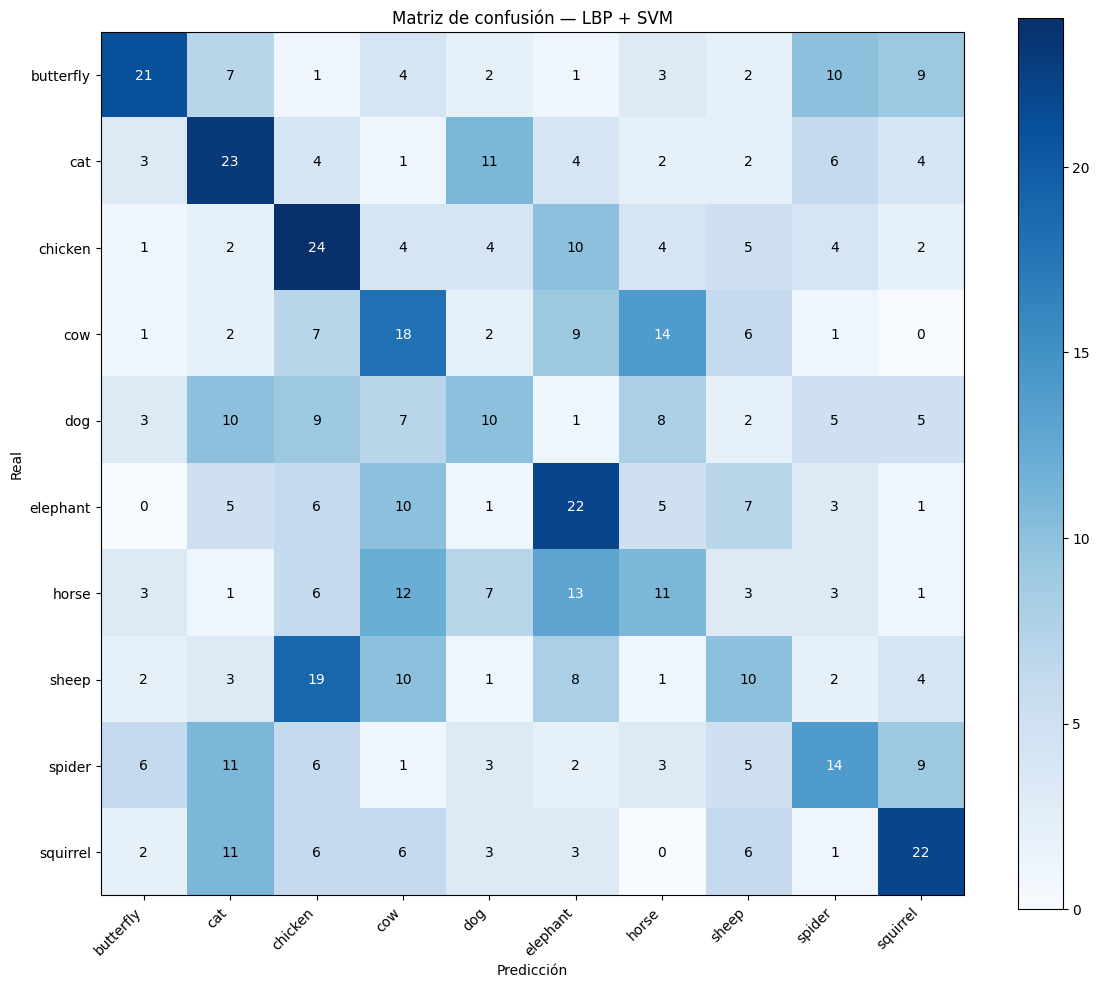

Matriz guardada en confusion_matrix_lbp.png


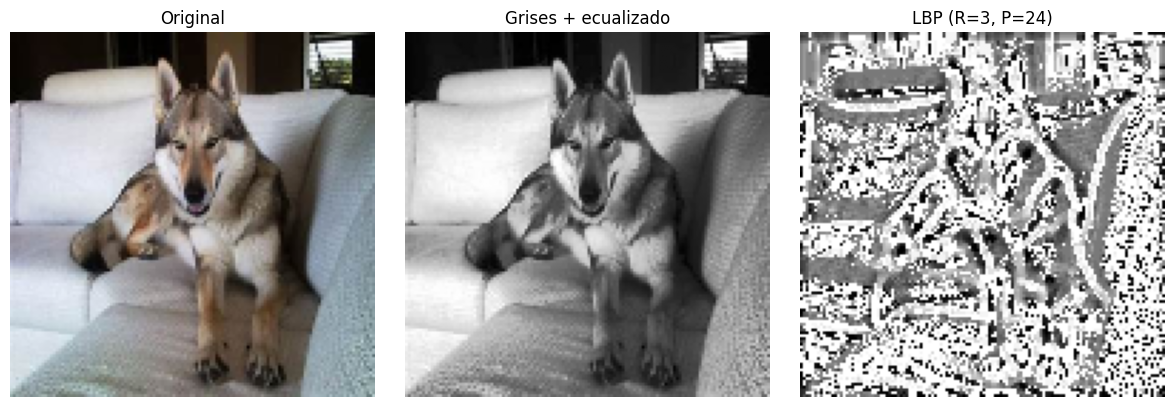


Modelo guardado en lbp_svm_model.pkl


In [5]:
"""
Extracción de características LBP (Local Binary Patterns)
para el dataset Animals-10 de Kaggle.

Estructura esperada del dataset:
    animals10/
        raw-img/
            cane/       (dog)
            ragno/      (spider)
            gallina/    (chicken)
            ...

Requiere:
    pip install scikit-image scikit-learn opencv-python numpy matplotlib tqdm
"""

import os
import numpy as np
import cv2
from skimage.feature import local_binary_pattern
from skimage.color import rgb2gray
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm


# ──────────────────────────────────────────────
# CONFIGURACIÓN
# ──────────────────────────────────────────────

path = "/kaggle/input/animals10/raw-img"   # <-- cambia esta ruta a tu dataset
IMG_SIZE     = (128, 128)            # resize uniforme
LBP_RADIUS   = 3                     # radio del vecindario LBP
LBP_POINTS   = 8 * LBP_RADIUS       # puntos = 8 * radio (recomendado)
LBP_METHOD   = "uniform"             # "uniform" reduce de 256 a 59 bins
                                     # otras opciones: "default", "ror", "nri_uniform"

# Traducción clase italiano → inglés (para los gráficos)
CLASS_NAMES = {
    "cane": "dog", "ragno": "spider", "gallina": "chicken",
    "cavallo": "horse", "farfalla": "butterfly", "mucca": "cow",
    "scoiattolo": "squirrel", "pecora": "sheep",
    "gatto": "cat", "elefante": "elephant"
}


# ──────────────────────────────────────────────
# 1. PREPROCESAMIENTO
# ──────────────────────────────────────────────

def preprocess_image(img_path: str) -> np.ndarray | None:
    """
    Carga, redimensiona y convierte a escala de grises una imagen.
    Retorna None si la imagen no se puede leer.
    """
    img = cv2.imread(img_path)
    if img is None:
        return None

    img = cv2.resize(img, IMG_SIZE)

    # Conversión a escala de grises (LBP opera sobre intensidad)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Ecualización de histograma: normaliza el brillo
    img_eq = cv2.equalizeHist(img_gray)

    return img_eq


# ──────────────────────────────────────────────
# 2. EXTRACCIÓN LBP
# ──────────────────────────────────────────────

def extract_lbp(image: np.ndarray) -> np.ndarray:
    """
    Extrae el histograma LBP de una imagen en escala de grises.

    Con method="uniform" obtenemos 59 bins en lugar de 256,
    que son los patrones "uniformes" (≤ 2 transiciones 0→1 ó 1→0).
    Estos patrones capturan bordes, esquinas y superficies planas,
    que son los más informativos para texturas.

    Retorna: vector 1D normalizado de longitud n_bins.
    """
    lbp_image = local_binary_pattern(
        image,
        P=LBP_POINTS,
        R=LBP_RADIUS,
        method=LBP_METHOD
    )

    # Número de bins según el método
    if LBP_METHOD == "uniform":
        n_bins = LBP_POINTS + 2     # 26 para P=24, 59 para P=24... depende de P
    else:
        n_bins = int(lbp_image.max()) + 1

    hist, _ = np.histogram(lbp_image.ravel(), bins=n_bins,
                           range=(0, n_bins), density=True)
    return hist


# ──────────────────────────────────────────────
# 3. CARGA DEL DATASET
# ──────────────────────────────────────────────

def load_dataset(dataset_path: str, max_per_class: int = 500):
    """
    Recorre las carpetas del dataset y extrae características LBP
    de cada imagen.

    max_per_class limita imágenes por clase para acelerar el entrenamiento
    en pruebas. Usa None para usar todas las imágenes.
    """
    features, labels = [], []
    class_dirs = sorted([d for d in os.listdir(dataset_path)
                         if os.path.isdir(os.path.join(dataset_path, d))])

    print(f"Clases encontradas: {class_dirs}\n")

    for class_name in class_dirs:
        class_path = os.path.join(dataset_path, class_name)
        image_files = [f for f in os.listdir(class_path)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        if max_per_class:
            image_files = image_files[:max_per_class]

        english_name = CLASS_NAMES.get(class_name, class_name)
        print(f"  Procesando {english_name:12s} ({len(image_files)} imágenes)...")

        for fname in tqdm(image_files, desc=f"  {english_name}", leave=False):
            img_path = os.path.join(class_path, fname)
            img = preprocess_image(img_path)
            if img is None:
                continue

            feat = extract_lbp(img)
            features.append(feat)
            labels.append(english_name)

    return np.array(features), np.array(labels)


# ──────────────────────────────────────────────
# 4. ENTRENAMIENTO CON SVM
# ──────────────────────────────────────────────

def train_svm(X_train, y_train):
    """
    Entrena un SVM con kernel RBF sobre los vectores LBP.
    StandardScaler normaliza las características antes de entrenar.
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    clf = SVC(
        kernel="rbf",
        C=10,               # penalización por error (ajustar con GridSearch)
        gamma="scale",      # gamma automático basado en varianza
        random_state=42,
        verbose=True
    )
    clf.fit(X_train_scaled, y_train)

    return clf, scaler


# ──────────────────────────────────────────────
# 5. EVALUACIÓN Y MÉTRICAS
# ──────────────────────────────────────────────

def evaluate(clf, scaler, X_test, y_test, class_names):
    X_test_scaled = scaler.transform(X_test)
    y_pred = clf.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {acc:.4f} ({acc*100:.2f}%)\n")
    print("Reporte de clasificación:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred, labels=class_names)
    plot_confusion_matrix(cm, class_names)

    return y_pred


def plot_confusion_matrix(cm, class_names):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title("Matriz de confusión — LBP + SVM")

    # Anotar cada celda
    thresh = cm.max() / 2
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j],
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.savefig("confusion_matrix_lbp.png", dpi=150)
    plt.show()
    print("Matriz guardada en confusion_matrix_lbp.png")


# ──────────────────────────────────────────────
# 6. VISUALIZAR LBP DE UNA IMAGEN
# ──────────────────────────────────────────────

def visualize_lbp(img_path: str):
    """
    Muestra la imagen original, la imagen en grises
    y la imagen LBP lado a lado. Útil para entender
    qué está capturando el descriptor.
    """
    img_color = cv2.imread(img_path)
    img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
    img_color = cv2.resize(img_color, IMG_SIZE)

    img_gray = cv2.cvtColor(img_color, cv2.COLOR_RGB2GRAY)
    img_eq   = cv2.equalizeHist(img_gray)

    lbp_image = local_binary_pattern(img_eq, P=LBP_POINTS,
                                     R=LBP_RADIUS, method=LBP_METHOD)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_color); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(img_eq, cmap="gray"); axes[1].set_title("Grises + ecualizado"); axes[1].axis("off")
    axes[2].imshow(lbp_image, cmap="gray"); axes[2].set_title(f"LBP (R={LBP_RADIUS}, P={LBP_POINTS})"); axes[2].axis("off")

    plt.tight_layout()
    plt.savefig("lbp_visualization.png", dpi=150)
    plt.show()


# ──────────────────────────────────────────────
# 7. CLASIFICAR UNA IMAGEN NUEVA
# ──────────────────────────────────────────────

def predict_image(img_path: str, clf, scaler, le: LabelEncoder):
    """
    Clasifica una imagen nueva usando el modelo entrenado.
    """
    img = preprocess_image(img_path)
    if img is None:
        print("No se pudo leer la imagen.")
        return

    feat = extract_lbp(img).reshape(1, -1)
    feat_scaled = scaler.transform(feat)

    pred_encoded = clf.predict(feat_scaled)[0]
    proba = clf.decision_function(feat_scaled)[0]  # scores por clase

    print(f"Predicción: {pred_encoded}")

    # Top-3 clases más probables
    top3_idx = np.argsort(proba)[::-1][:3]
    print("Top 3:")
    for i in top3_idx:
        print(f"  {le.classes_[i]:12s}  score={proba[i]:.3f}")


# ──────────────────────────────────────────────
# MAIN
# ──────────────────────────────────────────────

if __name__ == "__main__":

    # 1. Cargar y extraer características
    print("=== Extrayendo características LBP ===")
    X, y = load_dataset(path, max_per_class=300)
    print(f"\nTotal imágenes procesadas: {len(X)}")
    print(f"Dimensión del vector LBP:  {X.shape[1]}")   # 26 bins con uniform, P=24

    # 2. Codificar etiquetas
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    class_names = list(le.classes_)

    # 3. Split train/test (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

    # 4. Entrenar
    print("\n=== Entrenando SVM ===")
    clf, scaler = train_svm(X_train, y_train)

    # 5. Evaluar
    print("\n=== Evaluando ===")
    evaluate(clf, scaler, X_test, y_test, class_names)

    # 6. Visualizar LBP de una imagen de ejemplo
    example_img = os.path.join(path, "cane",
                               os.listdir(os.path.join(path, "cane"))[0])
    visualize_lbp(example_img)

    # 7. Guardar modelo (opcional)
    import pickle
    with open("lbp_svm_model.pkl", "wb") as f:
        pickle.dump({"clf": clf, "scaler": scaler, "le": le}, f)
    print("\nModelo guardado en lbp_svm_model.pkl")